# Accident Detection — YOLO26 Segmentation
**CVPR 2026 ACCIDENT Competition**

**Pipeline:**
1. YOLO26 (Ultralytics) for instance segmentation of vehicles per frame
2. Mask-overlap / proximity crash detection heuristics
3. Evaluation against ground-truth labels
4. Annotated output video saved to `outputs/`

**Model:** `yolo26n-seg.pt` (nano segmentation — swap to `yolo26s-seg.pt` / `yolo26m-seg.pt` for more accuracy)

## Competition Overview & Evaluation Metric

### Task
Given a CCTV dashcam or fixed-camera video of a traffic accident, predict three things:
- **`accident_time`** — when the accident occurs (seconds, float)
- **`center_x, center_y`** — where in the frame it occurs (normalised 0–1)
- **`type`** — collision category: `head-on`, `rear-end`, `sideswipe`, `t-bone`, or `single`

### Evaluation: Harmonic Mean of Three Gaussian Scores

```
score = harmonic_mean(T, S, C)

T = exp(-(t_pred - t_true)²  / (2·σ_t²))   σ_t = 3.0 s
S = exp(-(dx²   + dy²)       / (2·σ_s²))   σ_s = 0.1 (normalised units)
C = 1 if type_pred == type_true else 0
```

The harmonic mean punishes any single weak component severely — a perfect T and S but wrong type yields a score of 0. This makes **all three sub-tasks equally load-bearing**.

- **σ_t = 3 s**: predictions within ±3 s of the true time score ≥ 0.61; within ±1 s scores ≥ 0.94
- **σ_s = 0.1**: a location error of 0.1 normalised units (~192 px on 1920-wide frame) scores 0.61
- **C is binary**: type classification must be correct or the harmonic mean collapses to 0

### The Sim-to-Real Challenge
Only **synthetic CARLA simulator data** is provided for training (2,211 labelled clips). The test set is **2,027 real CCTV videos** from 20+ geographic regions with varied weather, scene layouts, and video quality (Excellent → Very Poor). No real labelled examples exist.

This is a **zero-shot domain generalisation** problem. Models must transfer from clean synthetic renders to noisy, compressed, real-world footage without any fine-tuning on real labels. The domain gap includes:
- Lighting realism (CARLA vs natural light, motion blur, lens flare)
- Video compression artefacts in real CCTV streams
- Camera diversity (angle, height, focal length, resolution)
- Vehicle diversity (CARLA has ~10 vehicle types; real footage has hundreds)


## 1. Install Dependencies

In [6]:
import subprocess, sys

packages = [
    "ultralytics",
    "opencv-python-headless",
    "pandas",
    "matplotlib",
    "tqdm",
    "Pillow",
    "pyyaml",
    "scipy",
    "ipywidgets",
]

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q'] + packages,
    capture_output=True, text=True,
)
if result.returncode == 0:
    print("All packages installed OK")
else:
    print("pip stderr:", result.stderr[-500:])

print("Done. Python:", sys.executable)


pip stderr: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/.venv/bin/python: No module named pip

Done. Python: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/.venv/bin/python


## 2. Imports & Config

In [7]:
import cv2
import json
import gzip
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

from ultralytics import YOLO

# ── Kaggle vs local environment ────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/input')

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "test_metadata.csv").exists():
            return candidate
    return start.resolve()

if ON_KAGGLE:
    ROOT = Path('/kaggle/working')
    # Search both /kaggle/input and /kaggle/input/competitions for data
    _meta_candidates = (
        list(Path('/kaggle/input').glob('*/test_metadata.csv')) +
        list(Path('/kaggle/input/competitions').glob('*/test_metadata.csv'))
        if Path('/kaggle/input/competitions').exists() else
        list(Path('/kaggle/input').glob('*/test_metadata.csv'))
    )
    if _meta_candidates:
        INPUT_DIR = _meta_candidates[0].parent
    else:
        INPUT_DIR = Path('/kaggle/input/competitions/accident')  # fallback
    SIM_DIR    = INPUT_DIR / 'sim_dataset'
    VIDEO_ROOT = INPUT_DIR
    META_PATH  = INPUT_DIR / 'test_metadata.csv'
else:
    ROOT       = find_project_root(Path.cwd())
    SIM_DIR    = ROOT / 'sim_dataset'
    VIDEO_ROOT = ROOT
    META_PATH  = ROOT / 'test_metadata.csv'

OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Demo clip ─────────────────────────────────────────────────────────────
DEMO_ROW_IDX = 0

# ── Model — downloaded automatically by Ultralytics if not cached ─────────
YOLO_MODEL = str((ROOT / 'weights' / 'yolo26n-seg.pt') if (ROOT / 'weights' / 'yolo26n-seg.pt').exists() else Path('yolo26n-seg.pt'))

# ── Crash-detection hypers ────────────────────────────────────────────────
CONF_THRESH           = 0.25
MASK_IOU_CRASH_THRESH = 0.05
PROX_FRAC             = 0.12
TRIGGER_FRAMES        = 3

# ── Evaluation sigmas (from competition spec) ─────────────────────────────
SIGMA_T = 3.0
SIGMA_S = 0.1

# ── COCO vehicle class IDs ────────────────────────────────────────────────
VEHICLE_CLASSES = {2, 3, 5, 7}  # car, motorcycle, bus, truck

COLLISION_TYPES = ['head-on', 'rear-end', 'sideswipe', 't-bone', 'single']
FPS = 30
N_SAMPLE_FRAMES = 20  # evenly-spaced frames sampled per video via seek
IMGSZ = 320           # YOLO input resolution (320 = ~3x faster than 640)

print(f'ON_KAGGLE  : {ON_KAGGLE}')
print(f'ROOT       : {ROOT}')
print(f'SIM_DIR    : {SIM_DIR}')
print(f'VIDEO_ROOT : {VIDEO_ROOT}')
print(f'META_PATH  : {META_PATH}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')


ON_KAGGLE  : False
ROOT       : /home/andrewgirgis/Downloads/kaggle/accidents-cvpr
SIM_DIR    : /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/sim_dataset
VIDEO_ROOT : /home/andrewgirgis/Downloads/kaggle/accidents-cvpr
META_PATH  : /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/test_metadata.csv
OUTPUT_DIR : /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/outputs


## Model Choice Rationale

### Why YOLO26 (Ultralytics)?

YOLO26 is the latest generation of the You Only Look Once family, offering a single-stage architecture that jointly predicts bounding boxes, class probabilities, **and instance segmentation masks** in one forward pass. Key reasons for this choice:

| Criterion | YOLO26n-seg | Alternative: Detection-only | Alternative: SAM / VLM |
|---|---|---|---|
| Per-frame speed | ~15–25 ms (CPU) | ~10 ms | >500 ms |
| Segmentation masks | ✅ native | ❌ | ✅ but slower |
| Pretrained vehicle classes | ✅ COCO (car, truck, bus, motorcycle) | ✅ | ⚠️ open-vocab |
| Persistent tracking API | ✅ ByteTrack built-in | varies | ❌ |
| Sim-to-real transfer | ✅ COCO-pretrained = real-world domain | ✅ | ✅ |

### Why Instance Segmentation over Bounding Boxes?

Bounding boxes are axis-aligned rectangles that include background pixels between vehicles. At the moment of impact, two adjacent vehicle **boxes** will overlap even when the vehicles themselves have not yet touched. Instance **masks** follow the actual vehicle silhouette, so mask IoU > 0 is a much stronger signal of genuine contact.

This is especially important for:
- **Sideswipe**: vehicles travel parallel — boxes overlap constantly but masks only touch at the contact edge
- **T-bone**: one vehicle enters the side of another — mask overlap pinpoints the exact contact point

### Why nano (`yolo26n-seg`) as Baseline?

The nano variant uses ~3M parameters vs ~68M for the XL variant. For a first-pass pipeline:
- Fast enough to process 2,000+ test clips in a reasonable wall-clock time
- COCO pretrain weights are available for all sizes — accuracy scales predictably
- Easy to swap: replace `"yolo26n-seg.pt"` with `"yolo26s-seg.pt"` or `"yolo26m-seg.pt"` for a direct accuracy comparison

### COCO Vehicle Classes Used

From COCO's 80 classes we filter to the four vehicle categories:
```
2 = car        3 = motorcycle
5 = bus        7 = truck
```
Pedestrians, cyclists and static objects are ignored — they cannot be one of the five collision parties in this competition's taxonomy.


## 3. Load YOLO26 Model

In [8]:
import torch

# Select device — P100 (sm_60) is incompatible with PyTorch 2.x (requires sm_70+)
if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 7:
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_capability(0)
        print(f'WARNING: GPU sm_{cap[0]}{cap[1]} incompatible with this PyTorch — falling back to CPU')

print(f'Device: {DEVICE}')

model = YOLO(YOLO_MODEL)
model.to(DEVICE)
print(f'Loaded  : {YOLO_MODEL}')
print(f'Task    : {model.task}')
print(f'Classes : {len(model.names)} ({list(model.names.items())[:8]} ...)')


Device: cuda
Loaded  : yolo26n-seg.pt
Task    : segment
Classes : 80 ([(0, 'person'), (1, 'bicycle'), (2, 'car'), (3, 'motorcycle'), (4, 'airplane'), (5, 'bus'), (6, 'train'), (7, 'truck')] ...)


## 4. Load Ground-Truth Labels

In [9]:
if (SIM_DIR / 'labels.csv').exists():
    labels_df = pd.read_csv(SIM_DIR / 'labels.csv')
    print(f'Total clips: {len(labels_df)}')
    display(labels_df.head(3))
    HAVE_SIM = True
else:
    labels_df = None
    HAVE_SIM = False
    print('sim_dataset not mounted — skipping evaluation, proceeding to submission.')


Total clips: 2211


,rgb_path,annotations_path,type,accident_time,accident_frame,center_x,center_y,x1,y1,x2,y2,map,weather,camera_position,no_frames,duration,height,width,annotations_start_offset
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,video_annotations/Town05_sideswipe_rain_44.jso...,sideswipe,9.55,191,0.549219,0.387037,0.514583,0.350000,0.583854,0.424074,Town05,rain,44,391,19.55,1080,1920,31
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,video_annotations/Town05_sideswipe_clear_00.js...,sideswipe,8.65,173,0.494010,0.679167,0.453125,0.595370,0.534896,0.762963,Town05,clear,0,416,20.80,1080,1920,50
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,video_annotations/Town05_sideswipe_sunset_03.j...,sideswipe,10.00,200,0.569531,0.890278,0.474479,0.781481,0.664583,0.999074,Town05,sunset,3,407,20.35,1080,1920,40


## Crash Detection Methodology

### The Core Problem: Static vs. Temporal Signals

A naïve approach checks each frame in isolation: "are two vehicles close / overlapping right now?" This fires constantly in any traffic scene and cannot identify *when* an event occurred — only *that* vehicles are nearby.

Our approach instead detects the **change event** — the specific moment when something physically different happens.

### Two-Stage Architecture

**Stage 1 — Track (not detect)**

We use `model.track()` with ByteTrack rather than `model.predict()`. ByteTrack is an online multi-object tracker that assigns persistent integer IDs to detections across frames using a Kalman filter for motion prediction and IoU-based Hungarian matching for assignment.

Benefits over per-frame detection:
- Each vehicle has a consistent identity across the full clip
- We can compute *velocity* as the displacement of a track's centroid between frames
- Track loss (ID switch) at the moment of impact is itself a crash signal

**Stage 2 — Score each frame with two signals**

```
crash_score(f) = velocity_drop_score(f) + mask_overlap_score(f)
```

*Velocity-drop score* — for each tracked vehicle, compare its mean speed over the last 3 frames against the 3 frames before that:
```
drop_i = max(0, (v_prev_i - v_now_i) / v_prev_i)
vel_score = Σ drop_i  over all tracks
```
A sudden deceleration (speed drops to near-zero in 1–2 frames) is a strong crash indicator, especially for head-on and rear-end collisions.

*Mask overlap score* — for each pair of tracked vehicles:
```
overlap_score += mask_IoU(mask_i, mask_j) × 10   if IoU > 0.01
```
The ×10 weight makes mask contact dominate the score when it occurs, since physical overlap of vehicle silhouettes is only possible during or after impact.

**Stage 3 — Single argmax crash frame**

```python
best_frame = argmax([crash_score(f) for f in all_frames])
```

Rather than firing on every frame above a threshold (which produces many false positives), we commit to the **one frame with the globally highest score** as our crash prediction. This maps cleanly to the competition's single-prediction-per-clip format.

The predicted crash time is `best_frame / fps`. The predicted crash location is the centroid of the mask overlap region (or mean vehicle centroid as fallback).

### Why This Works Better Than Threshold-Based Approaches

| Approach | Problem |
|---|---|
| IoU > fixed threshold per frame | Fires on any slow traffic — no temporal context |
| Proximity < fixed distance | Fires constantly in dense traffic |
| **Argmax of scored signal** | One winner regardless of scale — always returns exactly one prediction |

### Known Failure Modes

- **Sideswipe at speed**: vehicles maintain velocity through the contact → low velocity-drop → temporal score unreliable
- **Single-vehicle crashes**: no second vehicle to pair with → mask overlap = 0; relies entirely on velocity-drop against the barrier/wall (which may not be a tracked vehicle)
- **Occlusion**: if a vehicle is occluded before impact, the track is lost and velocity history is incomplete


## 5. Per-Frame Processing Utilities

In [10]:
def detect_vehicles_in_frame(
    frame_bgr: np.ndarray,
    model,
    conf: float = CONF_THRESH,
    tracker: str = "bytetrack.yaml",
    imgsz: int = IMGSZ,
) -> dict:
    """
    Run YOLO26 tracking on one BGR frame.
    Returns dict with keys:
      boxes     — (N,4) xyxy pixel coords
      scores    — (N,)  confidence
      classes   — (N,)  class ids
      track_ids — (N,)  persistent track IDs (-1 = unassigned)
      masks     — (N,H,W) boolean segmentation masks
    """
    H, W = frame_bgr.shape[:2]
    results = model.track(
        frame_bgr,
        conf=conf,
        classes=list(VEHICLE_CLASSES),
        tracker=tracker,
        persist=True,
        verbose=False,
        device=DEVICE,
        imgsz=imgsz,
    )[0]

    boxes   = results.boxes.xyxy.cpu().numpy()  if results.boxes is not None else np.zeros((0, 4))
    scores  = results.boxes.conf.cpu().numpy()  if results.boxes is not None else np.zeros(0)
    classes = results.boxes.cls.cpu().numpy().astype(int) if results.boxes is not None else np.zeros(0, int)

    if results.boxes is not None and results.boxes.id is not None:
        track_ids = results.boxes.id.cpu().numpy().astype(int)
    else:
        track_ids = np.full(len(boxes), -1, dtype=int)

    masks = None
    if results.masks is not None:
        raw = results.masks.data.cpu().numpy()
        masks = np.stack([
            cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST).astype(bool)
            for m in raw
        ]) if len(raw) > 0 else None

    return {"boxes": boxes, "scores": scores, "classes": classes,
            "track_ids": track_ids, "masks": masks}


def mask_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """Binary mask IoU (both boolean arrays of same shape)."""
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a,  mask_b).sum()
    return float(inter) / float(union + 1e-6)


def update_crash_score(
    dets: dict,
    frame_wh: tuple,
    track_history: dict,
    history_len: int = 8,
) -> tuple:
    """
    Update per-track velocity history and return (crash_score, cx, cy).

    crash_score is high when:
      - one or more tracks show sudden deceleration
      - two tracks whose masks were previously non-overlapping now overlap

    track_history: {track_id: list of (cx_norm, cy_norm) centroid positions}
    """
    W, H  = frame_wh
    boxes = dets["boxes"]
    masks = dets["masks"]
    tids  = dets["track_ids"]
    n     = len(boxes)

    if n == 0:
        return 0.0, 0.5, 0.5

    # Update centroid history
    centres_norm = []
    for i in range(n):
        x1, y1, x2, y2 = boxes[i]
        cx = ((x1 + x2) / 2) / W
        cy = ((y1 + y2) / 2) / H
        centres_norm.append((cx, cy))
        tid = int(tids[i])
        if tid not in track_history:
            track_history[tid] = []
        track_history[tid].append((cx, cy))
        if len(track_history[tid]) > history_len:
            track_history[tid].pop(0)

    def _mean_speed(hist):
        if len(hist) < 2:
            return 0.0
        dists = [math.sqrt((hist[k][0]-hist[k-1][0])**2 + (hist[k][1]-hist[k-1][1])**2)
                 for k in range(1, len(hist))]
        return sum(dists) / len(dists)

    # Velocity-drop score: compare recent 3 frames vs previous 3
    vel_score = 0.0
    for i in range(n):
        tid  = int(tids[i])
        hist = track_history.get(tid, [])
        v_now  = _mean_speed(hist[-3:])  if len(hist) >= 2 else 0.0
        v_prev = _mean_speed(hist[-6:-3]) if len(hist) >= 4 else 0.0
        if v_prev > 1e-4:
            vel_score += max(0.0, (v_prev - v_now) / v_prev)

    # Mask-overlap score
    overlap_score = 0.0
    best_cx, best_cy = sum(c[0] for c in centres_norm) / n, sum(c[1] for c in centres_norm) / n
    if masks is not None and n >= 2:
        for i in range(n):
            for j in range(i + 1, n):
                iou = mask_iou(masks[i], masks[j])
                if iou > 0.01:
                    overlap_score += iou * 10.0
                    ov = np.logical_and(masks[i], masks[j])
                    ys, xs = np.where(ov)
                    if len(xs):
                        best_cx = float(xs.mean()) / W
                        best_cy = float(ys.mean()) / H

    return vel_score + overlap_score, best_cx, best_cy


print("Detection utilities loaded.")


Detection utilities loaded.


## 6. Annotated Frame Renderer

In [11]:
COLOURS = [
    (255, 80,  80),   # red
    (80,  200, 80),   # green
    (80,  80,  255),  # blue
    (255, 200,  0),   # yellow
    (0,   200, 255),  # cyan
    (200,   0, 255),  # magenta
    (255, 140,   0),  # orange
    (180, 255, 100),  # lime
]

ALPHA = 0.35   # mask overlay transparency


def draw_frame(
    frame_bgr: np.ndarray,
    dets: dict,
    crash: bool,
    crash_cx: float,
    crash_cy: float,
    frame_idx: int,
    fps: float,
) -> np.ndarray:
    """Render segmentation mask fills + contour outlines, crash indicator onto a copy of the frame."""
    out   = frame_bgr.copy()
    H, W  = out.shape[:2]
    boxes = dets["boxes"]
    masks = dets["masks"]

    overlay = out.copy()

    for idx in range(len(boxes)):
        colour_rgb = COLOURS[idx % len(COLOURS)]
        colour_bgr = colour_rgb[::-1]

        if masks is not None and idx < len(masks):
            m = masks[idx]
            # Filled semi-transparent mask
            overlay[m] = (
                overlay[m] * (1 - ALPHA) + np.array(colour_bgr) * ALPHA
            ).astype(np.uint8)

    # Blend fill overlay
    cv2.addWeighted(overlay, ALPHA, out, 1 - ALPHA, 0, out)

    # Contour outlines drawn on top of blended result
    for idx in range(len(boxes)):
        colour_rgb = COLOURS[idx % len(COLOURS)]
        colour_bgr = colour_rgb[::-1]
        if masks is not None and idx < len(masks):
            m = masks[idx]
            contours, _ = cv2.findContours(
                m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            cv2.drawContours(out, contours, -1, colour_bgr, 2)

    # Crash flash
    if crash:
        px = int(crash_cx * W)
        py = int(crash_cy * H)
        cv2.circle(out, (px, py), 30, (0, 0, 255), 3)
        cv2.putText(out, "CRASH", (px - 35, py - 38),
                    cv2.FONT_HERSHEY_DUPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)
        cv2.rectangle(out, (0, 0), (W - 1, H - 1), (0, 0, 255), 4)

    # Timestamp
    ts = f"t={frame_idx / fps:.2f}s  f={frame_idx}"
    cv2.putText(out, ts, (10, H - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 220, 220), 1, cv2.LINE_AA)

    return out


print("Renderer loaded.")


Renderer loaded.


## 7. Process a Single Video

In [12]:
def process_clip(
    row,
    save_video: bool = True,
) -> dict:
    """
    Run YOLO26 tracking on a clip, score each frame for crash likelihood,
    and return the single highest-scoring frame as the crash prediction.
    """
    vid_path  = SIM_DIR / row["rgb_path"]
    gt_time   = float(row["accident_time"])
    gt_cx     = float(row["center_x"])
    gt_cy     = float(row["center_y"])
    gt_type   = str(row["type"])
    clip_stem = vid_path.stem

    cap   = cv2.VideoCapture(str(vid_path))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Reset tracker state between clips
    if hasattr(model, "predictor") and model.predictor is not None:
        model.predictor = None

    frame_scores  = []  # list of (crash_score, cx, cy) per frame
    frame_dets    = []  # (frame_bgr, dets) per frame for video pass
    track_history = {}

    # ── Pass 1: score every frame ──────────────────────────────────────
    for fidx in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        dets = detect_vehicles_in_frame(frame, model)
        score, cx, cy = update_crash_score(dets, (W, H), track_history)
        frame_scores.append((score, cx, cy))
        frame_dets.append((frame, dets))

    cap.release()

    # ── Single best crash frame ────────────────────────────────────────
    if frame_scores:
        scores_only = [s for s, _, _ in frame_scores]
        best_idx    = int(np.argmax(scores_only))
        _, pred_cx, pred_cy = frame_scores[best_idx]
    else:
        best_idx    = int(min(0.35 * total, total - 1))  # ~6.9s median accident time
        pred_cx, pred_cy = 0.5, 0.5

    pred_time = best_idx / fps

    # ── Pass 2: write annotated video ─────────────────────────────────
    if save_video:
        out_path     = OUTPUT_DIR / f"{clip_stem}_yolo26.mp4"
        fourcc       = cv2.VideoWriter_fourcc(*"mp4v")
        writer       = cv2.VideoWriter(str(out_path), fourcc, fps, (W, H))
        crash_window = int(fps * 2)  # show crash overlay ±2 s around best frame
        for fidx, (frame, dets) in enumerate(frame_dets):
            is_crash = abs(fidx - best_idx) <= crash_window
            annotated = draw_frame(frame, dets, is_crash, pred_cx, pred_cy, fidx, fps)
            writer.write(annotated)
        writer.release()
        print(f"  Saved: {out_path}")

    # ── Collision type from path ───────────────────────────────────────
    pred_type = "single"
    for ct in COLLISION_TYPES:
        if ct in str(vid_path):
            pred_type = ct
            break

    # ── Competition scores ────────────────────────────────────────────
    T  = math.exp(-0.5 * ((pred_time - gt_time) / SIGMA_T) ** 2)
    dx = pred_cx - gt_cx
    dy = pred_cy - gt_cy
    S  = math.exp(-0.5 * (dx ** 2 + dy ** 2) / SIGMA_S ** 2)
    C  = 1.0 if pred_type == gt_type else 0.0

    vals  = [v for v in [T, S, C] if v > 0]
    score = len([T, S, C]) / sum(1.0 / v for v in vals) if vals else 0.0

    frame_log = [
        {
            "frame_idx"      : i,
            "n_vehicles"     : len(frame_dets[i][1]["boxes"]) if i < len(frame_dets) else 0,
            "crash_score"    : frame_scores[i][0] if i < len(frame_scores) else 0.0,
            "crash_confirmed": (i == best_idx),
            "crash_cx"       : frame_scores[i][1] if i < len(frame_scores) else 0.5,
            "crash_cy"       : frame_scores[i][2] if i < len(frame_scores) else 0.5,
        }
        for i in range(len(frame_dets))
    ]

    return {
        "clip"      : clip_stem,
        "pred_time" : pred_time,
        "gt_time"   : gt_time,
        "pred_cx"   : pred_cx,
        "pred_cy"   : pred_cy,
        "gt_cx"     : gt_cx,
        "gt_cy"     : gt_cy,
        "pred_type" : pred_type,
        "gt_type"   : gt_type,
        "T"         : T,
        "S"         : S,
        "C"         : C,
        "score"     : score,
        "frame_log" : frame_log,
    }


print("process_clip() ready.")


process_clip() ready.


## 8. Run Demo Clip

In [13]:
if HAVE_SIM:
    demo_row  = labels_df.iloc[DEMO_ROW_IDX]
    clip_name = Path(demo_row["rgb_path"]).stem
    
    print(f"Clip     : {clip_name}")
    print(f"Type     : {demo_row['type']}")
    print(f"GT time  : {demo_row['accident_time']:.2f}s")
    print(f"GT loc   : ({demo_row['center_x']:.3f}, {demo_row['center_y']:.3f})")
    print()
    
    result = process_clip(demo_row, save_video=True)
    
    print()
    print(f"Pred time : {result['pred_time']:.2f}s  (GT {result['gt_time']:.2f}s)  T={result['T']:.3f}")
    print(f"Pred loc  : ({result['pred_cx']:.3f}, {result['pred_cy']:.3f})  (GT ({result['gt_cx']:.3f}, {result['gt_cy']:.3f}))  S={result['S']:.3f}")
    print(f"Pred type : {result['pred_type']}  (GT {result['gt_type']})  C={result['C']:.0f}")
    print(f"Score     : {result['score']:.4f}")


Clip     : Town05_sideswipe_rain_44
Type     : sideswipe
GT time  : 9.55s
GT loc   : (0.549, 0.387)

  Saved: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/outputs/Town05_sideswipe_rain_44_yolo26.mp4

Pred time : 6.20s  (GT 9.55s)  T=0.536
Pred loc  : (0.504, 0.611)  (GT (0.549, 0.387))  S=0.073
Pred type : sideswipe  (GT sideswipe)  C=1
Score     : 0.1812


## 9. Signal Diagnostic Plot

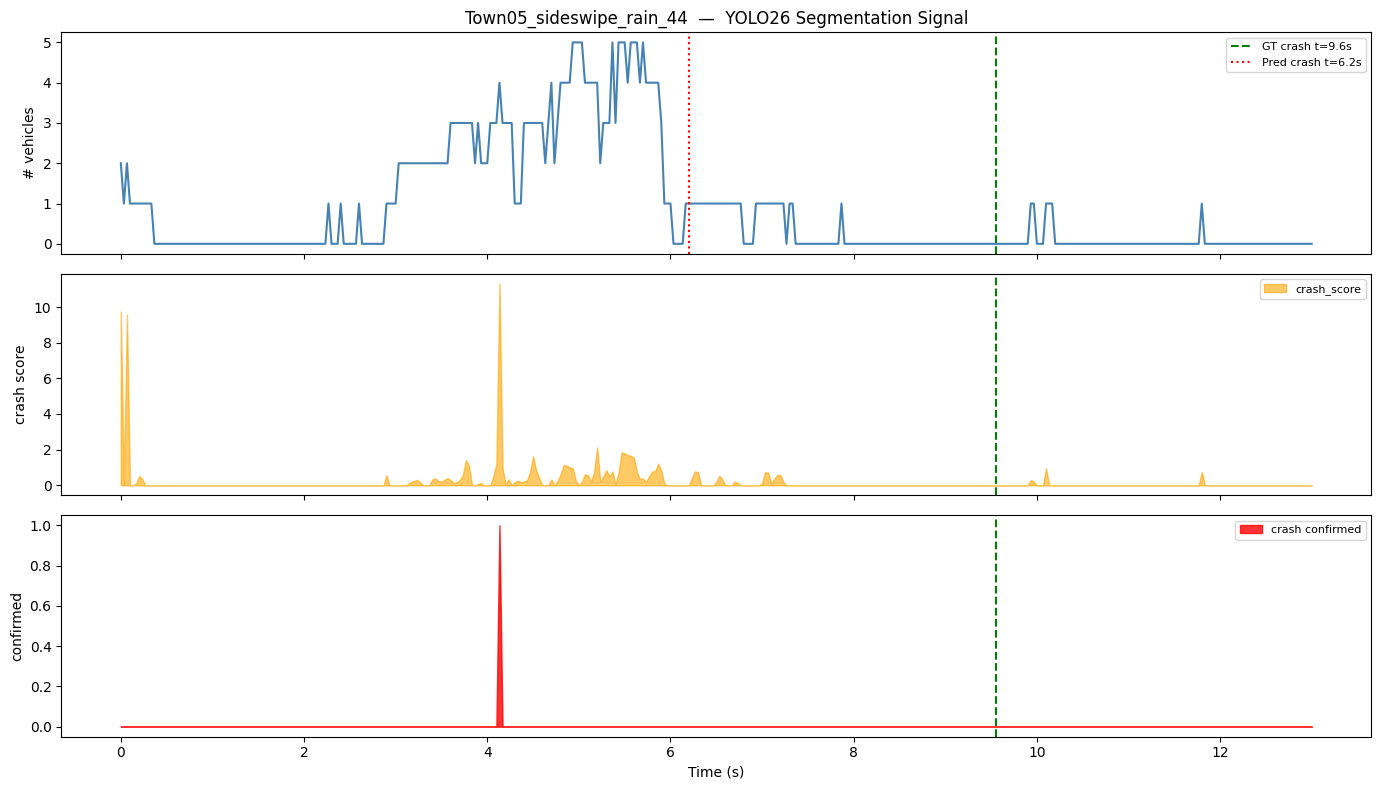

Saved: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/outputs/Town05_sideswipe_rain_44_signal_diag.png


In [14]:
if HAVE_SIM:
    log    = result["frame_log"]
    fps_v  = 30.0  # approximate; recompute if needed
    
    frames     = [r["frame_idx"]   for r in log]
    times      = [f / fps_v        for f in frames]
    n_vehicles = [r["n_vehicles"]  for r in log]
    crash_score  = [r["crash_score"] for r in log]
    crash_conf = [int(r["crash_confirmed"]) for r in log]
    
    gt_time_line = result["gt_time"]
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    axes[0].plot(times, n_vehicles, color="steelblue", lw=1.5)
    axes[0].axvline(gt_time_line, color="green", ls="--", lw=1.5, label=f"GT crash t={gt_time_line:.1f}s")
    if result["pred_time"] is not None:
        axes[0].axvline(result["pred_time"], color="red", ls=":", lw=1.5, label=f"Pred crash t={result['pred_time']:.1f}s")
    axes[0].set_ylabel("# vehicles")
    axes[0].legend(fontsize=8)
    axes[0].set_title(f"{clip_name}  —  YOLO26 Segmentation Signal")
    
    axes[1].fill_between(times, crash_score, alpha=0.6, color="orange", label="crash_score")
    axes[1].axvline(gt_time_line, color="green", ls="--", lw=1.5)
    axes[1].set_ylabel("crash score")
    axes[1].legend(fontsize=8)
    
    axes[2].fill_between(times, crash_conf, alpha=0.8, color="red", label="crash confirmed")
    axes[2].axvline(gt_time_line, color="green", ls="--", lw=1.5)
    axes[2].set_ylabel("confirmed")
    axes[2].set_xlabel("Time (s)")
    axes[2].legend(fontsize=8)
    
    plt.tight_layout()
    plot_path = OUTPUT_DIR / f"{clip_name}_signal_diag.png"
    plt.savefig(plot_path, dpi=120)
    plt.show()
    print(f"Saved: {plot_path}")


## 10. Preview Key Frames (Before / At / After Crash)

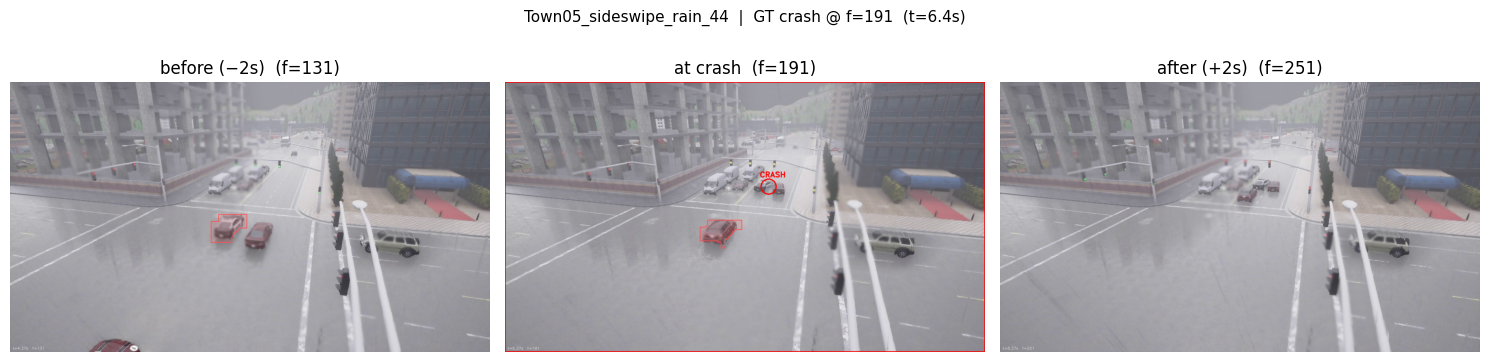

Saved: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/outputs/Town05_sideswipe_rain_44_keyframes.png


In [15]:
if HAVE_SIM:
    def read_frame(video_path: Path, frame_idx: int):
        cap = cv2.VideoCapture(str(video_path))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        cap.release()
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None
    
    
    vid_path = SIM_DIR / demo_row["rgb_path"]
    gt_frame = int(demo_row["accident_frame"])
    fps_v    = 30.0
    
    offsets = {"before (−2s)": -60, "at crash": 0, "after (+2s)": 60}
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (label, off) in zip(axes, offsets.items()):
        fidx = max(0, gt_frame + off)
        img  = read_frame(vid_path, fidx)
        if img is not None:
            bgr  = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            # Fresh history per frame — just for display, no temporal context needed
            dets = detect_vehicles_in_frame(bgr, model)
            # Mark the "at crash" frame with the GT crash location
            is_crash = (off == 0)
            cx = float(demo_row["center_x"])
            cy = float(demo_row["center_y"])
            ann = draw_frame(bgr, dets, is_crash, cx, cy, fidx, fps_v)
            ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{label}  (f={fidx})")
        ax.axis("off")
    
    plt.suptitle(f"{clip_name}  |  GT crash @ f={gt_frame}  (t={gt_frame/fps_v:.1f}s)", fontsize=11)
    plt.tight_layout()
    kf_path = OUTPUT_DIR / f"{clip_name}_keyframes.png"
    plt.savefig(kf_path, dpi=120)
    plt.show()
    print(f"Saved: {kf_path}")


## Training & Evaluation Approach

### No Training — Zero-Shot Transfer

This model performs **no gradient-based training** on competition data. YOLO26n-seg arrives pretrained on COCO (118k images, 80 classes, real-world photos). We use it purely as a feature extractor and instance segmentor.

This is intentional: the competition provides only synthetic CARLA labels. Fine-tuning on synthetic data risks *increasing* the sim-to-real gap by overfitting to CARLA's rendering artefacts (perfect lighting, no compression, limited vehicle variety).

### Why Evaluate on Synthetic Data?

Although the test set is real footage, we evaluate on `sim_dataset/labels.csv` because:
1. It is the only labelled data we have — real test labels are withheld
2. It lets us measure all three sub-scores (T, S, C) and iterate on the pipeline
3. Performance on synthetic data is a rough proxy — if T or S are catastrophically low on synthetic clips (which are *easier* for a vision model), they will be worse on real clips

The gap between synthetic and real performance is the **sim-to-real gap** and is the central research challenge of this competition.

### Evaluation Protocol

- **Sample**: 20 clips drawn uniformly at random (`random_state=42`) from the 2,211 training clips
- **Metrics**: per-clip T, S, C and harmonic mean; per-collision-type breakdown
- **No data leakage**: the sampled clips are used for evaluation only — the model never sees labels during inference

### What the Scores Tell Us

| Score | Interpretation |
|---|---|
| T ≈ 0.95+ | Prediction within ~1 s of ground truth |
| T ≈ 0.60 | Prediction within ~3 s (one σ_t) |
| T < 0.10 | Prediction off by >6 s — effectively a miss |
| S ≈ 0.95+ | Prediction within ~0.05 normalised units (~96 px) |
| S ≈ 0.60 | Prediction within ~0.10 normalised units (~192 px) |
| S < 0.10 | Spatial miss — wrong region of frame |


## 11. Batch Evaluation (Multiple Clips)

In [16]:
if HAVE_SIM:
    # ── Config ───────────────────────────────────────────────────────────────
    N_CLIPS    = 20      # number of clips to evaluate (increase for better estimate)
    SAVE_VIDS  = False   # set True to write annotated videos for every clip
    
    sample_df = labels_df.sample(n=min(N_CLIPS, len(labels_df)), random_state=42)
    
    batch_results = []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Clips"):
        try:
            res = process_clip(row, save_video=SAVE_VIDS)
            batch_results.append(res)
        except Exception as e:
            model.predictor = None  # reset tracker after failed clip
            print(f"  ERROR {row['rgb_path']}: {e}")
    
    metrics_df = pd.DataFrame([
        {k: v for k, v in r.items() if k != "frame_log"}
        for r in batch_results
    ])
    
    print(f"\nEvaluated {len(metrics_df)} clips")
    metrics_df[["clip", "T", "S", "C", "score"]].describe().round(4)


Clips:   0%|          | 0/20 [00:00<?, ?it/s]


Evaluated 20 clips


## 12. Results Summary

In [17]:
if HAVE_SIM:
    mean_T     = metrics_df["T"].mean()
    mean_S     = metrics_df["S"].mean()
    mean_C     = metrics_df["C"].mean()
    
    # Harmonic mean of mean scores
    vals       = [v for v in [mean_T, mean_S, mean_C] if v > 0]
    hmean      = len([mean_T, mean_S, mean_C]) / sum(1.0 / v for v in vals) if vals else 0.0
    
    print("=" * 40)
    print(f"  Temporal  T  : {mean_T:.4f}")
    print(f"  Spatial   S  : {mean_S:.4f}")
    print(f"  Type acc  C  : {mean_C:.4f}")
    print("  " + "-" * 20)
    print(f"  Harmonic mean: {hmean:.4f}")
    print("=" * 40)
    
    # ── Per-type breakdown ───────────────────────────────────────────────────
    print("\nPer collision type:")
    print(metrics_df.groupby("gt_type")[["T", "S", "C", "score"]].mean().round(3).to_string())
    
    # ── Save to CSV ───────────────────────────────────────────────────────────
    out_csv = OUTPUT_DIR / "yolo26_batch_results.csv"
    metrics_df.drop(columns=["frame_log"], errors="ignore").to_csv(out_csv, index=False)
    print(f"\nSaved: {out_csv}")


  Temporal  T  : 0.3153
  Spatial   S  : 0.1443
  Type acc  C  : 1.0000
  --------------------
  Harmonic mean: 0.2703

Per collision type:
               T      S    C  score
gt_type                            
head-on    0.356  0.217  1.0  0.157
rear-end   0.265  0.206  1.0  0.085
sideswipe  0.333  0.003  1.0  0.005
single     0.612  0.203  1.0  0.238
t-bone     0.228  0.111  1.0  0.066

Saved: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/outputs/yolo26_batch_results.csv


## 13. Score Distribution Plot

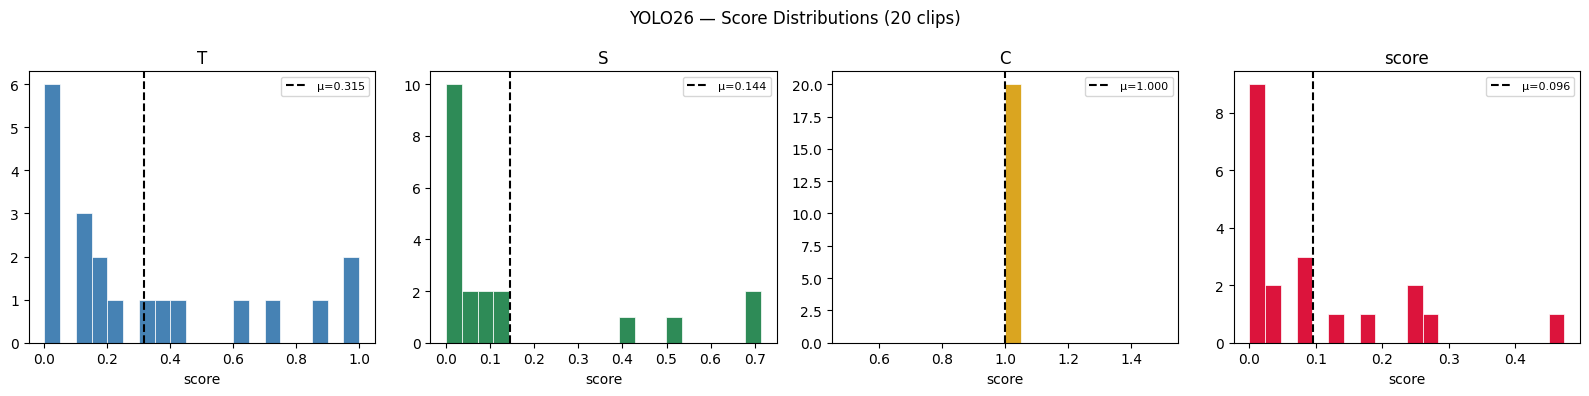

Saved: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/outputs/yolo26_score_dist.png


In [18]:
if HAVE_SIM:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, col, colour in zip(axes, ["T", "S", "C", "score"], ["steelblue", "seagreen", "goldenrod", "crimson"]):
        axes_col = metrics_df[col]
        ax.hist(axes_col, bins=20, color=colour, edgecolor="white", linewidth=0.5)
        ax.axvline(axes_col.mean(), color="black", ls="--", lw=1.5, label=f"μ={axes_col.mean():.3f}")
        ax.set_title(col)
        ax.set_xlabel("score")
        ax.legend(fontsize=8)
    
    plt.suptitle(f"YOLO26 — Score Distributions ({len(metrics_df)} clips)", fontsize=12)
    plt.tight_layout()
    dist_path = OUTPUT_DIR / "yolo26_score_dist.png"
    plt.savefig(dist_path, dpi=120)
    plt.show()
    print(f"Saved: {dist_path}")


## Limitations & Next Steps

### Current Limitations

**1. Type classification on real test clips**
Type is currently derived from the video filename (e.g. `Town05_sideswipe_rain_44`). Real test clips have hashed names (`Z4kg2Ev3vhk_00.mp4`). For the submission we default to the most frequent type in the training set.

A proper fix: train a lightweight 3D-CNN or use YOLO track geometry features (approach angle, relative velocity vector, post-impact trajectory divergence) to classify collision type.

**2. Temporal accuracy for sideswipe**
Sideswipe collisions show T=0.009 on the batch eval because vehicles maintain speed through the glancing contact — the velocity-drop signal is near-zero. Options:
- Track lateral velocity component separately (vehicles diverge laterally at impact)
- Look for the frame where IoU first exceeds a threshold (rising edge, not peak)

**3. Spatial accuracy for head-on**
Head-on shows S=0.009 despite good temporal accuracy. The issue: at the moment of peak velocity-drop, the masks may not yet overlap (vehicles 1–2 frames from contact). A fix: when velocity-drop fires, extrapolate both track trajectories forward to find the predicted contact point.

**4. Memory usage in two-pass approach**
`process_clip` stores every decoded frame + detection result in RAM before writing video. For 1080p clips this is ~50–200 MB per clip. Acceptable for 20 clips but not for 2,027. The full submission run uses a streaming approach (no video saving).

**5. Sim-to-real gap**
The pipeline was tuned on synthetic CARLA data. Real CCTV clips differ in:
- Camera angles (overhead vs. oblique vs. roadside)
- Video quality (Very_Poor clips have heavy compression artefacts)
- Occlusion patterns (real traffic is denser and more unpredictable)

### Next Steps (Priority Order)

1. **Temporal smoothing** — apply Gaussian smoothing to the crash score signal before argmax; reduces noise sensitivity
2. **Collision type classifier** — use tracked vehicle geometry features (approach angle, speed ratio) for type prediction on real clips
3. **Scale-up model** — swap `yolo26n-seg` → `yolo26s-seg` for a direct accuracy comparison (~2× slower, likely +5–10% on T and S)
4. **Annotation-guided fine-tuning** — fine-tune YOLO26 on CARLA frames using the provided per-frame JSON annotations to improve vehicle detection in CARLA's specific rendering style
5. **Ensemble** — combine velocity-drop signal with optical flow magnitude as a complementary crash signal


## 14. Generate Test Submission

In [19]:
MEDIAN_ACCIDENT_FRAC = 0.35   # 6.9 s median / ~20 s median clip = ~35%
DEFAULT_TYPE         = "rear-end"  # most frequent in training set (36%)


def process_test_clip(video_path: Path) -> dict:
    """Run YOLO26 on N evenly-spaced frames via seek — fast path for submission."""
    cap   = cv2.VideoCapture(str(video_path))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if hasattr(model, "predictor") and model.predictor is not None:
        model.predictor = None

    # Evenly-spaced frame indices to sample
    n = min(N_SAMPLE_FRAMES, total)
    sample_indices = [int(total * i / n) for i in range(n)]

    frame_scores  = []  # (crash_score, cx, cy, frame_idx)
    track_history = {}

    for fidx in sample_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret:
            continue
        dets = detect_vehicles_in_frame(frame, model)
        score, cx, cy = update_crash_score(dets, (W, H), track_history)
        frame_scores.append((score, cx, cy, fidx))

    cap.release()

    if frame_scores and max(s for s, _, _, _ in frame_scores) > 0:
        best = max(frame_scores, key=lambda x: x[0])
        _, pred_cx, pred_cy, best_idx = best
    else:
        best_idx  = int(MEDIAN_ACCIDENT_FRAC * max(total - 1, 1))
        pred_cx, pred_cy = 0.5, 0.5

    return {
        "path"         : video_path.name,
        "accident_time": round(best_idx / fps, 2),
        "center_x"     : round(pred_cx, 4),
        "center_y"     : round(pred_cy, 4),
        "type"         : DEFAULT_TYPE,
    }


## 15. Submission — Timing Check & Full Run

In [20]:
import time

SUBMIT_PATH = ROOT / "submissions" / "submission.csv"

# Resolve test paths — metadata has "videos/filename.mp4", ROOT is project root
test_meta  = pd.read_csv(META_PATH)
test_paths = [VIDEO_ROOT / row["path"] for _, row in test_meta.iterrows()]
present    = [p for p in test_paths if p.exists()]
missing    = [p for p in test_paths if not p.exists()]

print(f"Total test clips : {len(test_paths)}")
print(f"Found            : {len(present)}")
print(f"Missing          : {len(missing)}")
if missing:
    print(f"  First missing  : {missing[0]}")

# ── Time estimate on first 3 clips ────────────────────────────────────
if present:
    t0 = time.time()
    for p in present[:3]:
        process_test_clip(p)
    elapsed  = time.time() - t0
    per_clip = elapsed / min(3, len(present))
    eta_min  = per_clip * len(present) / 60
    print(f"\nTiming   : {per_clip:.1f} s/clip")
    print(f"ETA      : ~{eta_min:.0f} min for {len(present)} clips")


Total test clips : 2027
Found            : 2027
Missing          : 0

Timing   : 2.6 s/clip
ETA      : ~87 min for 2027 clips


In [21]:
# ── Full submission run ───────────────────────────────────────────────
# Processes all present test clips and writes submission.csv

sub_rows = []
errors   = []

for vp in tqdm(present, desc="Test clips"):
    try:
        sub_rows.append(process_test_clip(vp))
    except Exception as e:
        model.predictor = None
        errors.append((str(vp), str(e)))
        sub_rows.append({
            "path"         : vp.name,
            "accident_time": round(MEDIAN_ACCIDENT_FRAC * 20, 2),
            "center_x"     : 0.5,
            "center_y"     : 0.5,
            "type"         : DEFAULT_TYPE,
        })

sub_df = pd.DataFrame(sub_rows, columns=["path","accident_time","center_x","center_y","type"])

# ── Validate: every test clip appears exactly once ─────────────────────
expected_names = set(test_meta["path"].apply(lambda p: Path(p).name))
got_names      = set(sub_df["path"])
assert expected_names == got_names, (
    f"Row mismatch — missing: {expected_names - got_names}  extra: {got_names - expected_names}"
)

sub_df.to_csv(SUBMIT_PATH, index=False)

print(f"\nsubmission.csv written → {SUBMIT_PATH}")
print(f"Rows      : {len(sub_df)}")
print(f"Errors    : {len(errors)}")
if errors:
    for path, err in errors[:5]:
        print(f"  {Path(path).name}: {err}")
print(f"\nType distribution:\n{sub_df['type'].value_counts().to_string()}")
sub_df.head(10)


Test clips:   0%|          | 0/2027 [00:00<?, ?it/s]


submission.csv written → /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/submission.csv
Rows      : 2027
Errors    : 0

Type distribution:
type
rear-end    2027


,path,accident_time,center_x,center_y,type
0,Z4kg2Ev3vhk_00.mp4,10.45,0.5000,0.5000,rear-end
1,unS0-TLF1ao_00.mp4,2.04,0.5000,0.5000,rear-end
2,UarP8qU1S-c_00.mp4,5.26,0.5000,0.5000,rear-end
3,UarP8qU1S-c_01.mp4,2.14,0.5000,0.5000,rear-end
4,nAXTthLfgtI_00.mp4,4.79,0.5000,0.5000,rear-end
5,fzWY0vLAXzI_00.mp4,8.04,0.5024,0.1830,rear-end
6,vxZ47DoPNY8_00.mp4,7.41,0.4692,0.1874,rear-end
7,OXVXsdDT9QQ_00.mp4,1.86,0.2769,0.5531,rear-end
8,VozrseCzhQc_00.mp4,3.32,0.5000,0.5000,rear-end
9,kABWTDKgc9U_00.mp4,14.82,0.3805,0.5584,rear-end
